findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

Loading within_object_z_profile.csv from all datasets...

  rat_neurons_dodt: 8,256 rows, 8 models
  mice_neurons_dodt: 15,864 rows, 8 models
  human_neurons_dodt: 7,616 rows, 8 models
  rat_neurons_oblique: 5,856 rows, 8 models
  mice_neurons_oblique: 13,392 rows, 8 models
  human_neurons_oblique: 4,768 rows, 8 models

Total: 55,752 rows
Models: ['3D U-Net (aug)', '3D U-Net (no aug)', 'Cellpose', 'StarDist3D (aug)', 'StarDist3D (no aug)', 'nnU-Net', 'μSAM (fine-tuned)', 'μSAM (pretrained)']

Unmatched slices forced to Dice=0: 37,439 / 55,752 (67.2%)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

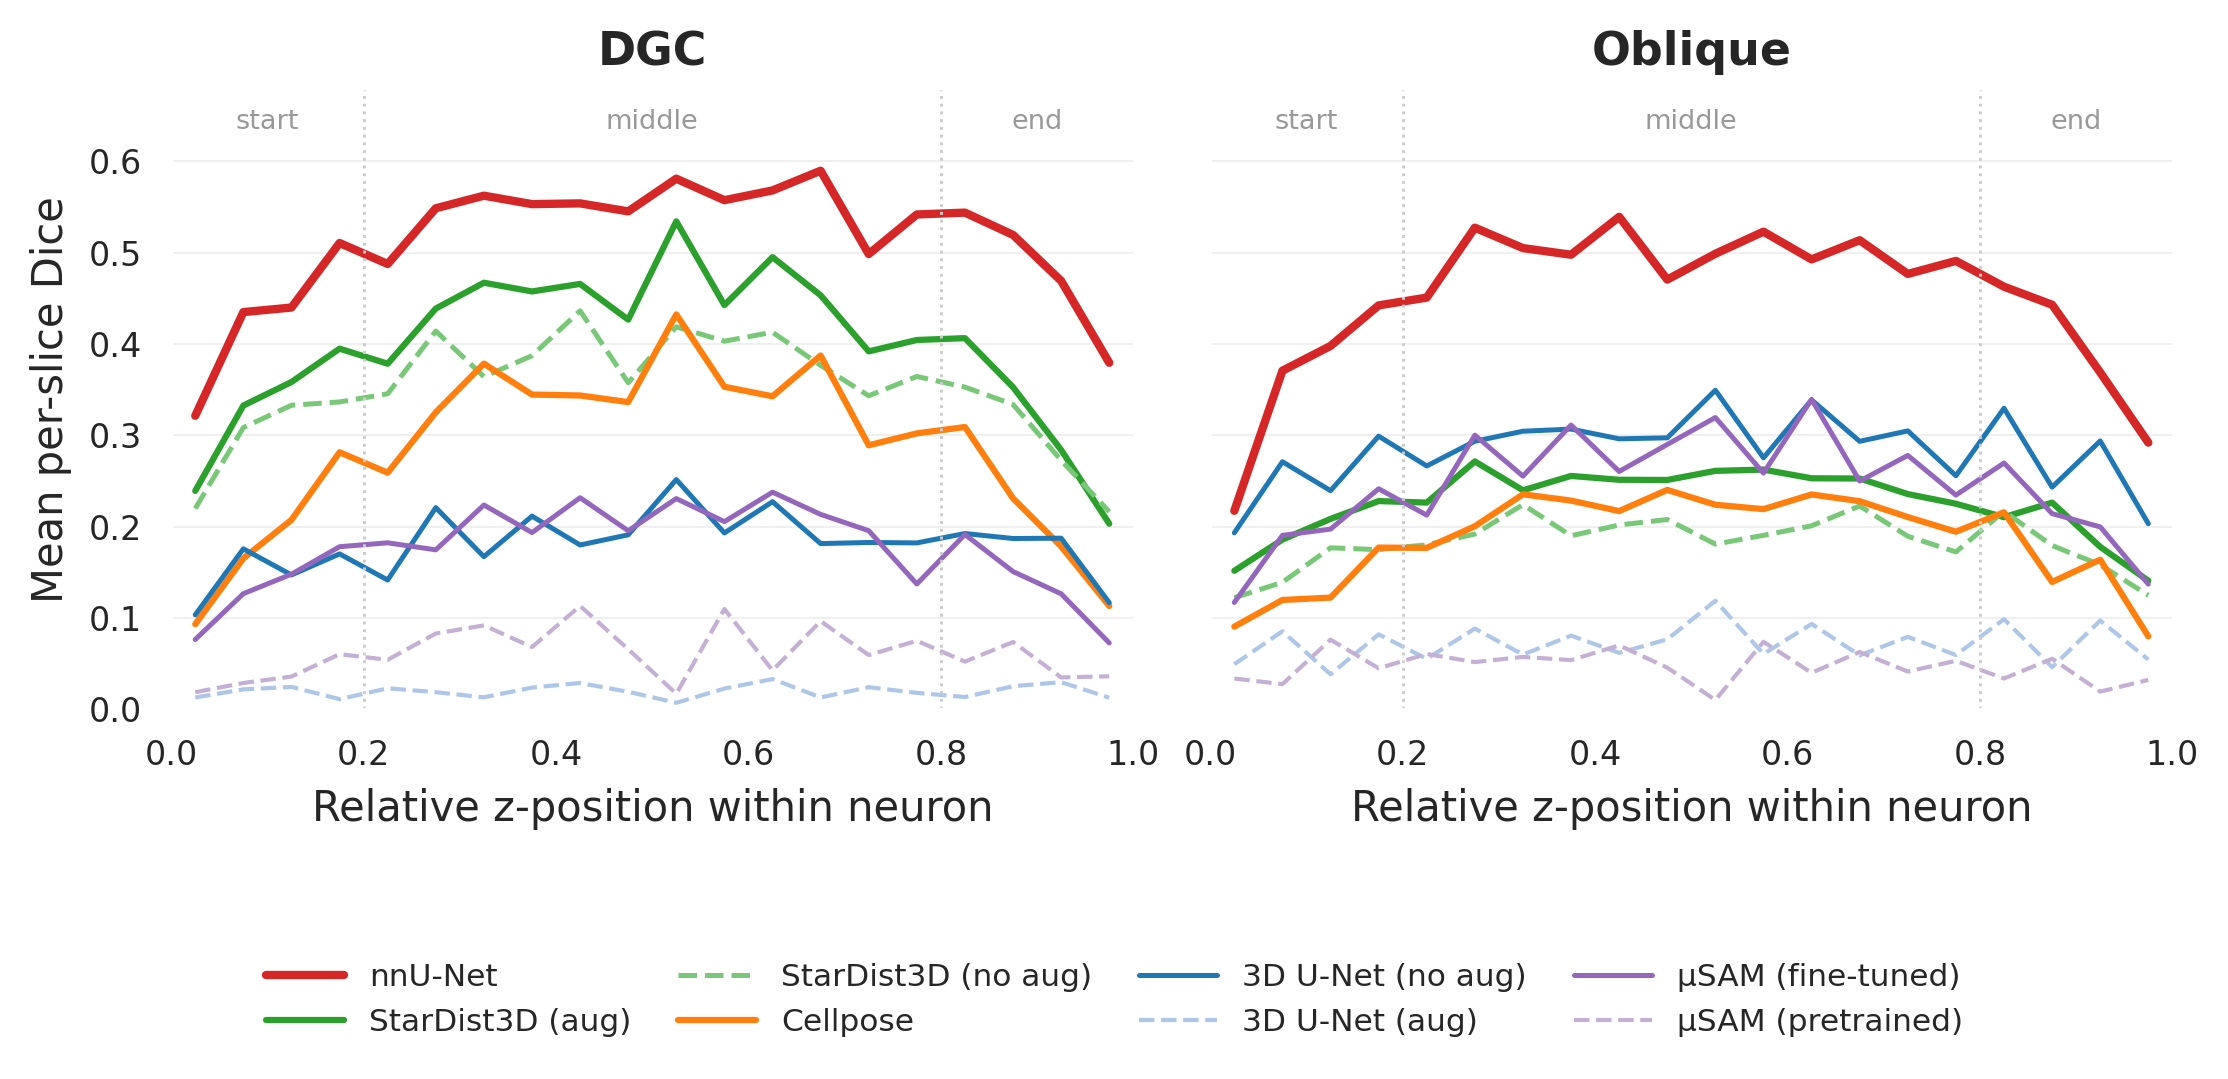


Saved: fig_z_profile_dice.pdf / .png
Auto ylim: 0.678 (data max: 0.590)

Mean Dice by zone (two-level avg, unmatched=0)

DGC:
  Model                         start    middle       end      drop
  ------------------------------------------------------------
  nnU-Net                       0.409     0.546     0.460    +0.112
  StarDist3D (aug)              0.314     0.441     0.291    +0.139
  StarDist3D (no aug)           0.284     0.382     0.278    +0.101
  Cellpose                      0.171     0.338     0.194    +0.155
  3D U-Net (no aug)             0.140     0.190     0.160    +0.040
  3D U-Net (aug)                0.017     0.021     0.018    +0.004
  μSAM (fine-tuned)             0.122     0.202     0.120    +0.081
  μSAM (pretrained)             0.033     0.075     0.049    +0.033

Oblique:
  Model                         start    middle       end      drop
  ------------------------------------------------------------
  nnU-Net                       0.333     0.496     0.383

In [6]:
"""
fig_z_profile_dice.py — Within-object z-profile: per-slice Dice vs relative Z.

Two panels: DGC (left) and Oblique (right), 8 models each.
Unmatched slices count as Dice=0 (no survivorship bias).
Two-level averaging: first per-dataset, then across datasets within modality.

Usage:
    python fig_z_profile_dice.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# ═══════════════════════════════════════════════════════════════════════════
#  CONFIG
# ═══════════════════════════════════════════════════════════════════════════

BASE = Path("/NAS/mmaiurov/datasets_benchmark")

DATASETS = {
    "rat_neurons_dodt":      "DGC",
    "mice_neurons_dodt":     "DGC",
    "human_neurons_dodt":    "DGC",
    "rat_neurons_oblique":   "Oblique",
    "mice_neurons_oblique":  "Oblique",
    "human_neurons_oblique": "Oblique",
}

def short_name(m):
    m = m.lower()
    if "nnunet" in m:                              return "nnU-Net"
    if "stardist" in m and ("lightaug" in m or "light_aug" in m):
                                                   return "StarDist3D (aug)"
    if "stardist" in m and ("noaug" in m or "no_aug" in m):
                                                   return "StarDist3D (no aug)"
    if "stardist" in m:                            return "StarDist3D (aug)"
    if "cellpose" in m:                            return "Cellpose"
    if "microsam" in m and "finetuned" in m:       return "μSAM (fine-tuned)"
    if "microsam" in m and "pretrained" in m:      return "μSAM (pretrained)"
    if "finetuned" in m or "fine_tuned" in m or "fine-tuned" in m:
                                                   return "μSAM (fine-tuned)"
    if "pretrained" in m:                          return "μSAM (pretrained)"
    if "unet3d" in m and ("light_aug" in m or "lightaug" in m):
                                                   return "3D U-Net (aug)"
    if "unet3d" in m and ("no_aug" in m or "noaug" in m):
                                                   return "3D U-Net (no aug)"
    if "unet3d" in m:                              return "3D U-Net (aug)"
    return m

MODEL_ORDER = [
    "nnU-Net",
    "StarDist3D (aug)",
    "StarDist3D (no aug)",
    "Cellpose",
    "3D U-Net (no aug)",
    "3D U-Net (aug)",
    "μSAM (fine-tuned)",
    "μSAM (pretrained)",
]

MODEL_COLORS = {
    "nnU-Net":             "#D62728",
    "StarDist3D (aug)":    "#2CA02C",
    "StarDist3D (no aug)": "#78C878",
    "Cellpose":            "#FF7F0E",
    "3D U-Net (no aug)":   "#1F77B4",
    "3D U-Net (aug)":      "#AEC7E8",
    "μSAM (fine-tuned)":   "#9467BD",
    "μSAM (pretrained)":   "#C5B0D5",
}

MODEL_LINESTYLES = {
    "nnU-Net":             "-",
    "StarDist3D (aug)":    "-",
    "StarDist3D (no aug)": "--",
    "Cellpose":            "-",
    "3D U-Net (no aug)":   "-",
    "3D U-Net (aug)":      "--",
    "μSAM (fine-tuned)":   "-",
    "μSAM (pretrained)":   "--",
}

MODEL_LINEWIDTHS = {
    "nnU-Net":             2.0,
    "StarDist3D (aug)":    1.5,
    "StarDist3D (no aug)": 1.2,
    "Cellpose":            1.5,
    "3D U-Net (no aug)":   1.2,
    "3D U-Net (aug)":      1.0,
    "μSAM (fine-tuned)":   1.2,
    "μSAM (pretrained)":   1.0,
}

N_BINS = 20
BIN_EDGES = np.linspace(0, 1, N_BINS + 1)
BIN_CENTERS = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2

# ═══════════════════════════════════════════════════════════════════════════
#  LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════

print("Loading within_object_z_profile.csv from all datasets...\n")

frames = []
for dataset_name, modality in DATASETS.items():
    csv_path = BASE / dataset_name / "results" / "evaluation" / "within_object_z_profile.csv"
    if not csv_path.exists():
        print(f"  SKIP: {csv_path}")
        continue
    df = pd.read_csv(csv_path)
    df["dataset"] = dataset_name
    df["modality"] = modality
    df["model_short"] = df["model"].apply(short_name)
    frames.append(df)
    print(f"  {dataset_name}: {len(df):,} rows, {df['model_short'].nunique()} models")

all_data = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(all_data):,} rows")
print(f"Models: {sorted(all_data['model_short'].unique())}")

# ═══════════════════════════════════════════════════════════════════════════
#  FORCE Dice=0 FOR UNMATCHED SLICES
# ═══════════════════════════════════════════════════════════════════════════

n_unmatched = (all_data["matched"] == False).sum()
print(f"\nUnmatched slices forced to Dice=0: {n_unmatched:,} / {len(all_data):,} "
      f"({100*n_unmatched/len(all_data):.1f}%)")
all_data.loc[all_data["matched"] == False, "slice_dice"] = 0.0

# ═══════════════════════════════════════════════════════════════════════════
#  BIN AND TWO-LEVEL AGGREGATE
# ═══════════════════════════════════════════════════════════════════════════

all_data["z_bin"] = pd.cut(
    all_data["z_rel"], bins=BIN_EDGES, labels=BIN_CENTERS, include_lowest=True
).astype(float)

# Level 1: mean per dataset × model × z_bin
level1 = all_data.groupby(["modality", "dataset", "model_short", "z_bin"]).agg(
    mean_dice=("slice_dice", "mean"),
).reset_index()

# Level 2: mean across datasets within modality
level2 = level1.groupby(["modality", "model_short", "z_bin"]).agg(
    dice_mean=("mean_dice", "mean"),
).reset_index()

# ═══════════════════════════════════════════════════════════════════════════
#  FIGURE
# ═══════════════════════════════════════════════════════════════════════════

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 7.5,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.2), sharey=True)

# Auto ylim from data
global_max = level2["dice_mean"].max()
ylim_top = min(global_max * 1.15, 1.0)  # 15% headroom, cap at 1.0
ylim_top = max(ylim_top, 0.1)  # at least 0.1

for ax, modality in zip(axes, ["DGC", "Oblique"]):
    sub = level2[level2["modality"] == modality]

    for model_name in MODEL_ORDER:
        m_data = sub[sub["model_short"] == model_name].sort_values("z_bin")
        if m_data.empty:
            continue

        x = m_data["z_bin"].values
        y = np.clip(m_data["dice_mean"].values, 0, ylim_top)

        color = MODEL_COLORS.get(model_name, "gray")
        ls = MODEL_LINESTYLES.get(model_name, "-")
        lw = MODEL_LINEWIDTHS.get(model_name, 1.2)

        ax.plot(x, y, color=color, linestyle=ls, linewidth=lw, label=model_name)

    # Zone boundaries
    ax.axvline(0.2, color='#CCCCCC', linestyle=':', linewidth=0.7)
    ax.axvline(0.8, color='#CCCCCC', linestyle=':', linewidth=0.7)

    ax.text(0.1, 0.97, "start", ha='center', va='top', fontsize=6.5,
            color='#999999', transform=ax.get_xaxis_transform())
    ax.text(0.5, 0.97, "middle", ha='center', va='top', fontsize=6.5,
            color='#999999', transform=ax.get_xaxis_transform())
    ax.text(0.9, 0.97, "end", ha='center', va='top', fontsize=6.5,
            color='#999999', transform=ax.get_xaxis_transform())

    ax.set_xlabel("Relative z-position within neuron")
    ax.set_title(modality, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, ylim_top)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color='#F0F0F0', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

axes[0].set_ylabel("Mean per-slice Dice")

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.12),
           columnspacing=1.5, handlelength=2.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25, wspace=0.08)

plt.savefig("fig_z_profile_dice.pdf", bbox_inches='tight')
plt.savefig("fig_z_profile_dice.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved: fig_z_profile_dice.pdf / .png")
print(f"Auto ylim: {ylim_top:.3f} (data max: {global_max:.3f})")

# ═══════════════════════════════════════════════════════════════════════════
#  SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("Mean Dice by zone (two-level avg, unmatched=0)")
print("=" * 80)

for modality in ["DGC", "Oblique"]:
    print(f"\n{modality}:")
    print(f"  {'Model':<25s}  {'start':>8s}  {'middle':>8s}  {'end':>8s}  {'drop':>8s}")
    print("  " + "-" * 60)

    mod_data = all_data[all_data["modality"] == modality]
    for model_name in MODEL_ORDER:
        m = mod_data[mod_data["model_short"] == model_name]
        if m.empty:
            continue

        zones = {}
        for zname in ["start", "middle", "end"]:
            if zname == "start":
                mask = m["z_rel"] <= 0.2
            elif zname == "end":
                mask = m["z_rel"] >= 0.8
            else:
                mask = (m["z_rel"] > 0.2) & (m["z_rel"] < 0.8)
            per_ds = m[mask].groupby("dataset")["slice_dice"].mean()
            zones[zname] = per_ds.mean() if len(per_ds) > 0 else np.nan

        drop = zones["middle"] - (zones["start"] + zones["end"]) / 2
        print(f"  {model_name:<25s}  {zones['start']:8.3f}  {zones['middle']:8.3f}  "
              f"{zones['end']:8.3f}  {drop:+8.3f}")